In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs_pure
import loglike_pure
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time




print(f"Using dt = {dt} seconds, T = {T} years")



print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs_pure.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")
# make this from log_density([param_true])
_TARGET_LOGLIKE = 5.90716261


def log_density(params):
    global _PARIS_EARLY_STOP_HIT
    params = np.asarray(params)

    def eval_one(x):
        global _PARIS_EARLY_STOP_HIT
        if _PARIS_EARLY_STOP_HIT:
            return float('-inf')
        try:
            logm1, logm2, a, p0, e0 = x
            m1 = 10**logm1
            m2 = 10**logm2

            fstat = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))            
        except Exception:
            return float('-inf')
        
        if fstat >= _TARGET_LOGLIKE:
            _PARIS_EARLY_STOP_HIT = True
            try:
                print(f"[EARLY-STOP] SNR {fstat:.6f} >= {_TARGET_LOGLIKE}; future calls => -inf")
            except Exception:
                pass

        return fstat
        
    if params.ndim == 1:
        return eval_one(params)
    out = np.zeros(params.shape[0], dtype=float)
    for i in range(params.shape[0]):
        out[i] = eval_one(params[i])
    return out

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...


In [2]:

# -----------------------------
# PARIS global context (picklable functions require module scope)
# -----------------------------
_PARIS_EARLY_STOP_HIT = False

# Fisher-parallelotope affine prior (primary for this script)
# _PARIS_AFFINE_CENTER = None       # type: Optional[np.ndarray]
# _PARIS_AFFINE_Q = None            # type: Optional[np.ndarray]
# _PARIS_AFFINE_B = None            # type: Optional[np.ndarray]
# # _PARIS_DIM = None                 # type: Optional[int]


In [3]:
# from Sdel_new
# best_fit = [6.00597255, 1.00197611, 0.71300743, 8.9263246 , 0.39821827]
#from S10_old
best_fit=[6.00556816, 1.00404448, 0.71049625, 8.94018508, 0.39701817]
log_density(best_fit)

-0.07634738509064364

In [13]:
from scipy.optimize import differential_evolution                                                                                                                                                                          
                                                                                                                                                                                                                        
# testing bounds
bounds = [
    (5.9990, 6.0001),   # logm1 
    (0.999,  1.004),    # logm2
    (0.695,  0.701),    # a
    (8.999,  9.025),    # p0
    (0.397,  0.401),    # e0
]                                                                                                                                                                                                                      
result_de = differential_evolution(                                                                                                                                                                                        
    neg_logden, bounds=bounds,  
    maxiter=2000, tol=1e-8, seed=42, disp=True,                                                                                                                                                                            
    popsize=15, mutation=(0.5, 1.0), recombination=0.7                                                                                                                                                                     
)                                                                                                                                                                                                                        
    

differential_evolution step 1: f(x)= -0.8861960133957962
differential_evolution step 2: f(x)= -0.8861960133957962
differential_evolution step 3: f(x)= -0.8861960133957962
differential_evolution step 4: f(x)= -0.8861960133957962
differential_evolution step 5: f(x)= -0.8861960133957962
differential_evolution step 6: f(x)= -0.8861960133957962
differential_evolution step 7: f(x)= -1.375482291584618
differential_evolution step 8: f(x)= -1.8117446335702039
differential_evolution step 9: f(x)= -1.8117446335702039
differential_evolution step 10: f(x)= -1.8117446335702039
differential_evolution step 11: f(x)= -1.8117446335702039
differential_evolution step 12: f(x)= -1.8117446335702039
differential_evolution step 13: f(x)= -1.8117446335702039
differential_evolution step 14: f(x)= -1.8117446335702039
differential_evolution step 15: f(x)= -1.8117446335702039
differential_evolution step 16: f(x)= -1.8117446335702039
differential_evolution step 17: f(x)= -1.8117446335702039
differential_evolution s

In [14]:
result_de.x

array([6.00008845, 1.00010046, 0.70013864, 8.99919968, 0.39993227])

# connection plots

In [18]:
proc1_maxld_pt = result_de.x.reshape(1,-1)
proc1_maxld_pt

array([[6.00008845, 1.00010046, 0.70013864, 8.99919968, 0.39993227]])

In [19]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [20]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [21]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


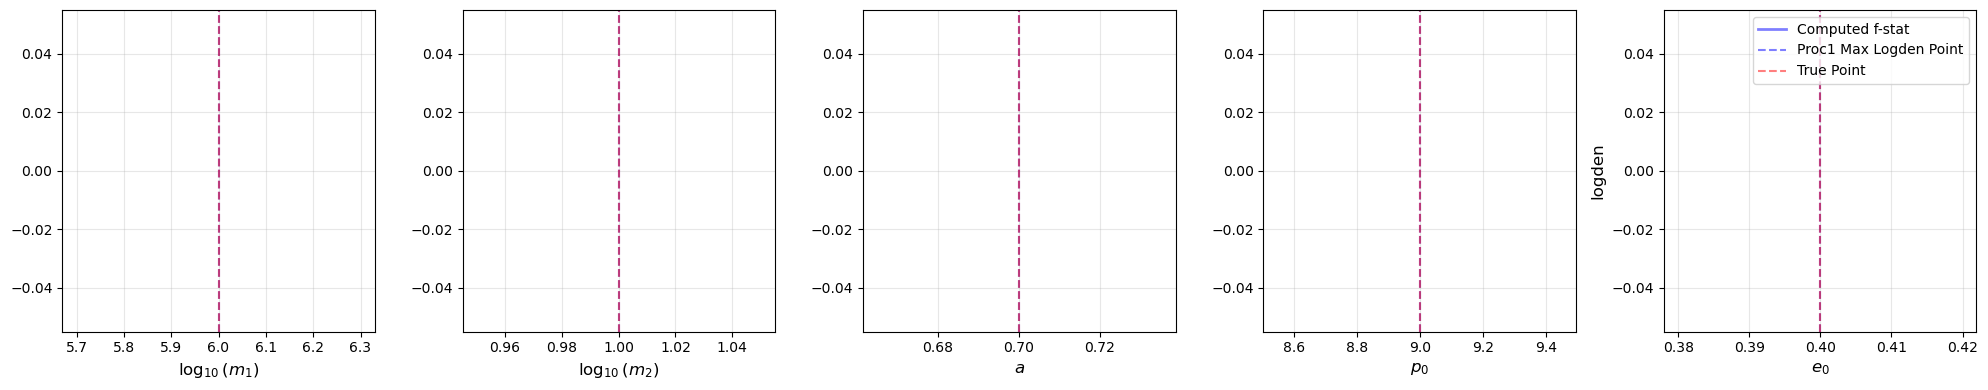

In [22]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


# from paris3_4

In [5]:
mu_center  = np.array([6.01487994, 1.00500901, 0.73205648, 8.81696887, 0.39543265])                                                                                                                                        
sigma_diag = np.array([0.00929708, 0.00521965, 0.01918811, 0.11027935, 0.00390186])                                                                                                                                        

N_sigma = 2                                                                                                                                                                                                           
half = N_sigma * sigma_diag                                                                                                                                                                                              
bounds = [(mu_center[i] - half[i], mu_center[i] + half[i]) for i in range(5)]     

In [6]:
bounds

[(np.float64(5.99628578), np.float64(6.0334741)),
 (np.float64(0.9945697099999999), np.float64(1.01544831)),
 (np.float64(0.69368026), np.float64(0.7704327)),
 (np.float64(8.59641017), np.float64(9.03752757)),
 (np.float64(0.38762893), np.float64(0.40323637))]

In [9]:
from scipy.optimize import differential_evolution                                                                                                                                                                          

_PARIS_EARLY_STOP_HIT = False

                               
def neg_logden(x):
    val = log_density(np.array([x]))[0]
    return -val if np.isfinite(val) else 1e10  
                                                                                                                                                                                
result_new = differential_evolution(                                                                                                                                                                                        
    neg_logden, bounds=bounds,  
    maxiter=2000, tol=1e-8, seed=42, disp=True,                                                                                                                                                                            
    popsize=15, mutation=(0.5, 1.0), recombination=0.7                                                                                                                                                                     
)        

differential_evolution step 1: f(x)= -0.052390758418639355
differential_evolution step 2: f(x)= -0.06926227487644686
differential_evolution step 3: f(x)= -0.06926227487644686
differential_evolution step 4: f(x)= -0.09703149178193642
differential_evolution step 5: f(x)= -0.10004447098632886
differential_evolution step 6: f(x)= -0.10004447098632886
differential_evolution step 7: f(x)= -0.10004447098632886
differential_evolution step 8: f(x)= -0.10004447098632886
differential_evolution step 9: f(x)= -0.10004447098632886
differential_evolution step 10: f(x)= -0.10004447098632886
differential_evolution step 11: f(x)= -0.10004447098632886
differential_evolution step 12: f(x)= -0.10004447098632886
differential_evolution step 13: f(x)= -0.10004447098632886
differential_evolution step 14: f(x)= -0.1070000619274353
differential_evolution step 15: f(x)= -0.1070000619274353
differential_evolution step 16: f(x)= -0.1070000619274353
differential_evolution step 17: f(x)= -0.1070000619274353
different

KeyboardInterrupt: 